In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

print(merged.shape)
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s', 'expellant_mass_kg', 'attr_mass']].dropna().head(10)

(66666, 59)


,OBJECT_NAME,altitude_km,deltav_km_s,expellant_mass_kg,attr_mass
0,OPS 3674 (VELA 4),110631.921857,1.2438,14.202,217.00
1,YZ-1 R/B,71550.191715,1.3697,150.035,2075.00
2,ASTRON,161495.854880,1.1180,185.966,3171.46
3,OPS 3662 (VELA 3),157847.293602,1.1258,13.406,227.00
4,CXO,130845.955703,1.1891,347.581,5563.00
5,SL-12 R/B(2),166611.346992,1.1073,123.141,2120.91
6,SOLRAD 11A/B AKM,122190.544513,1.2117,0.596,9.36
7,TITAN 3C TRANSTAGE R/B,117024.710806,1.2258,125.717,1950.00
8,TITAN 3C TRANSTAGE R/B,118453.039527,1.2218,95.520,1486.62
9,SOLRAD 11A,117718.082878,1.2239,11.547,179.39


In [3]:
# hall thruster specs
# thrust is tiny but super efficient — powered by solar panels!!
THRUST_N = 0.2      # newtons (typical hall thruster)
THRUST_KMS2 = THRUST_N / 1000  # converting to km/s2

# time = (mass * delta-v) / thrust
# basically newtons second law F = ma rearranged

def deorbit_time(mass_kg, dv_km_s):
    if pd.isna(mass_kg) or pd.isna(dv_km_s):
        return np.nan
    if mass_kg <= 0 or dv_km_s <= 0:
        return np.nan
    
    # total mass including expellant
    total_mass = mass_kg + merged.loc[merged['attr_mass'] == mass_kg, 'expellant_mass_kg'].iloc[0] if not pd.isna(mass_kg) else mass_kg
    
    time_seconds = (mass_kg * dv_km_s) / THRUST_KMS2
    time_days = time_seconds / 86400
    return round(time_days, 1)

merged['attr_mass'] = pd.to_numeric(merged['attr_mass'], errors='coerce')
merged['deorbit_days'] = merged.apply(
    lambda row: deorbit_time(row['attr_mass'], row['deltav_km_s']), axis=1
)

print("deorbit time calculated for", merged['deorbit_days'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'attr_mass', 'deltav_km_s', 'deorbit_days']].dropna().head(10)

deorbit time calculated for 20111 objects


,OBJECT_NAME,attr_mass,deltav_km_s,deorbit_days
0,OPS 3674 (VELA 4),217.00,1.2438,15.6
1,YZ-1 R/B,2075.00,1.3697,164.5
2,ASTRON,3171.46,1.1180,205.2
3,OPS 3662 (VELA 3),227.00,1.1258,14.8
4,CXO,5563.00,1.1891,382.8
5,SL-12 R/B(2),2120.91,1.1073,135.9
6,SOLRAD 11A/B AKM,9.36,1.2117,0.7
7,TITAN 3C TRANSTAGE R/B,1950.00,1.2258,138.3
8,TITAN 3C TRANSTAGE R/B,1486.62,1.2218,105.1
9,SOLRAD 11A,179.39,1.2239,12.7


In [4]:
print(merged[['deorbit_days']].dropna().describe())

print("\nfastest to deorbit:")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'attr_mass', 'deorbit_days', 'risk_label']].dropna().sort_values('deorbit_days').head(10)

       deorbit_days
count  20111.000000
mean      32.787022
std       91.290296
min        0.000000
25%        1.500000
50%        2.700000
75%        7.800000
max     2815.500000

fastest to deorbit:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deorbit_days,risk_label
66367,COSMOS 19,PAYLOAD,207.931598,351.83,0.0,LOW
66357,EXPLORER 9,PAYLOAD,375.530656,7.00,0.0,LOW
10761,ASTROCAST-0101,PAYLOAD,387.905699,5.00,0.0,HIGH
10759,OBJECT P,UNKNOWN,484.877738,3.20,0.0,MEDIUM
7570,OBJECT Y,UNKNOWN,505.098458,3.00,0.0,MEDIUM
7567,ELECTRON KICK STAGE R/B,ROCKET BODY,250.333569,55.00,0.0,HIGH
7537,OBJECT D,UNKNOWN,475.486489,3.00,0.0,MEDIUM
17619,UND ROADS 2,PAYLOAD,512.600394,5.40,0.0,MEDIUM
14051,INSPIRESAT-1,PAYLOAD,342.511107,8.10,0.0,HIGH
4758,FLOCK 4Q 4,PAYLOAD,444.749531,5.70,0.0,MEDIUM


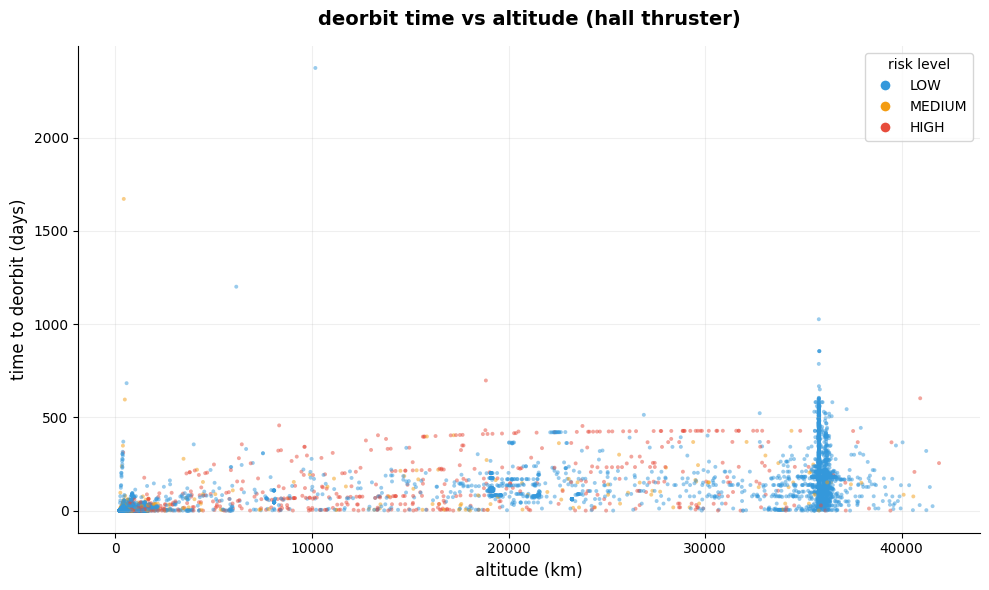

In [5]:
# deorbit time vs altitude
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[merged['altitude_km'].between(200, 42000)].dropna(subset=['deorbit_days'])
sample = sample[sample['deorbit_days'] < 10000]  # removing crazy outliers

colors = sample['risk_label'].map({'LOW': '#3498db', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'})

ax.scatter(sample['altitude_km'], sample['deorbit_days'],
           c=colors, s=8, alpha=0.5, edgecolors='none')

ax.set_title('deorbit time vs altitude (hall thruster)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('altitude (km)', fontsize=12)
ax.set_ylabel('time to deorbit (days)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='LOW'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='MEDIUM'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='HIGH'),
]
ax.legend(handles=legend, title='risk level')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12591/3863780635.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_time = merged.groupby('regime')['deorbit_days'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


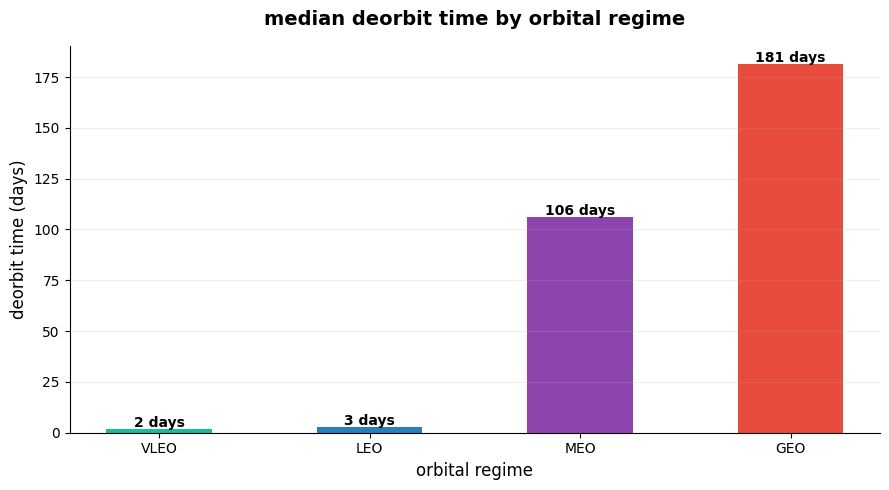

In [6]:
# median deorbit time per regime
fig, ax = plt.subplots(figsize=(9, 5))

regime_time = merged.groupby('regime')['deorbit_days'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ['#1abc9c', '#2980b9', '#8e44ad', '#e74c3c']

bars = ax.bar(regime_time.index, regime_time.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_time.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f} days', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median deorbit time by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('deorbit time (days)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
# most urgent — high risk objects and how long to deorbit them
print("high risk objects deorbit timeline:")
merged[merged['risk_label'] == 'HIGH'][['OBJECT_NAME', 'OBJECT_TYPE',
    'altitude_km', 'attr_mass', 'deltav_km_s', 'deorbit_days']].dropna().sort_values('deorbit_days').head(15)

high risk objects deorbit timeline:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deltav_km_s,deorbit_days
18235,SMDC ONE 2.3,PAYLOAD,410.059291,4.000,0.0605,0.0
1275,OBJECT F,UNKNOWN,366.902608,10.000,0.0484,0.0
38216,SPACEBEE-30,PAYLOAD,17188.680324,0.284,1.3967,0.0
52398,DELTA 1 DEB,DEBRIS,489721.626254,1.000,0.7514,0.0
38287,SPACEBEE-38,PAYLOAD,23929.169311,0.284,1.4616,0.0
801,OBJECT AA,UNKNOWN,337.480752,10.000,0.0400,0.0
10192,PACE-1,PAYLOAD,378.444108,10.000,0.0516,0.0
39057,CZ-2D DEB,DEBRIS,1941.171524,1.000,0.4177,0.0
37819,CZ-2D DEB,DEBRIS,2486.460315,1.000,0.5170,0.0
37433,SPACEBEENZ-1,PAYLOAD,24966.635097,0.284,1.4666,0.0


In [8]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with deorbit times!!", merged.shape)

saved with deorbit times!! (66666, 60)
